#

In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the packages.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import MNIST
from diffusers import UNet2DModel

Plotting the noise schedule of SMLD.

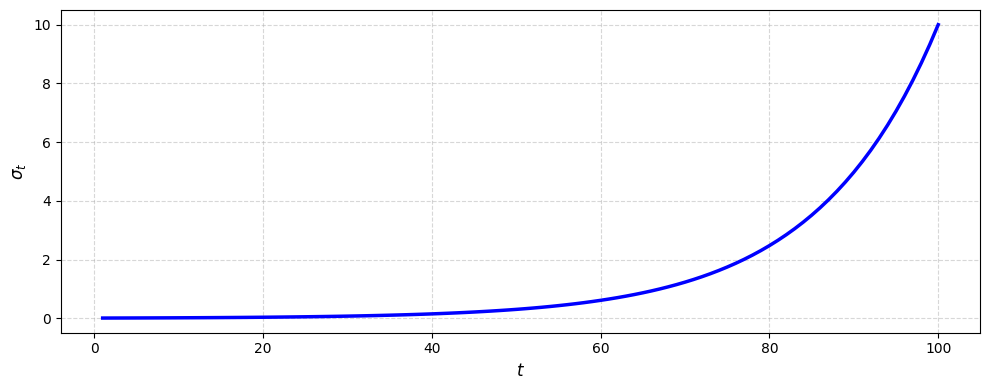

In [3]:
T = 100
sigma_1 = 0.01
sigma_T = 10.0

steps = np.arange(1, T + 1)
smld_sigmas = sigma_1 * ((sigma_T / sigma_1) ** ((steps - 1) / (T - 1)))

plt.figure(figsize=(10, 4))
plt.plot(steps, smld_sigmas, color="blue", linewidth=2.5)
plt.xlabel(r"$t$", fontsize=12)
plt.ylabel(r"$\sigma_t$", fontsize=12)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Showing the data corruption in different noise scales.

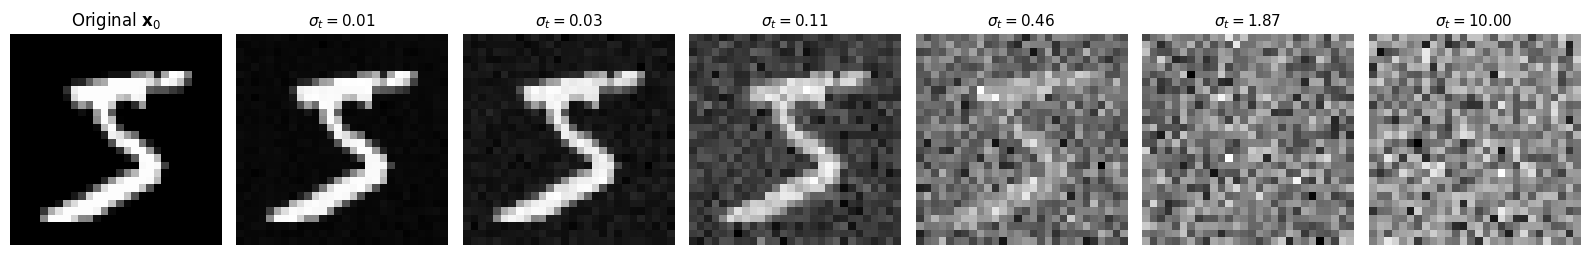

In [6]:
dataset = MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
x0, _ = dataset[0]
x0 = x0.unsqueeze(0)

selected_indices = [0, 15, 35, 55, 75, 99]
fig, axes = plt.subplots(1, len(selected_indices) + 1, figsize=(16, 3))

axes[0].imshow(x0.squeeze().numpy(), cmap="gray")
axes[0].set_title(r"Original $\mathbf{x}_0$", fontsize=12)
axes[0].axis("off")

for i, idx in enumerate(selected_indices):
    sigma = smld_sigmas[idx]
    z = torch.randn_like(x0)
    xt = x0 + sigma * z

    axes[i + 1].imshow(xt.squeeze().numpy(), cmap="gray")
    axes[i + 1].set_title(r"$\sigma_t=$" + f"{sigma:.2f}", fontsize=11)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()